In [13]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from PIL import Image
from modules.video import VideoReadManager

# Load images

In [23]:
os.makedirs("./imgs", exist_ok=True)  

for file_name in ["easy3.mp4", "medium3.mp4", "difficult3.mp4"]:
    with VideoReadManager(f"./videos/{file_name}") as reader:
        for frame in reader():
            img = Image.fromarray(frame)
            img.save("./imgs/" + file_name[:-5] + ".png")
            break

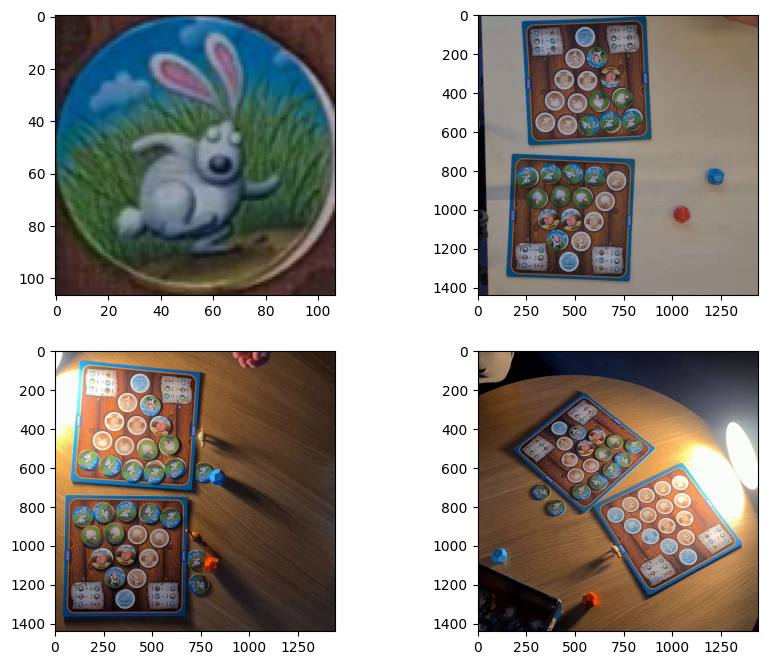

In [25]:
img_easy = np.array(Image.open("./imgs/easy.png"))
img_medium = np.array(Image.open("./imgs/medium.png"))
img_difficult = np.array(Image.open("./imgs/difficult.png"))
pattern = np.array(Image.open("./imgs/pattern.png"))[:, :, :3]

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
ax[0][0].imshow(pattern)
ax[0][1].imshow(img_easy)
ax[1][0].imshow(img_medium)
ax[1][1].imshow(img_difficult)
plt.show()

# Edges detection

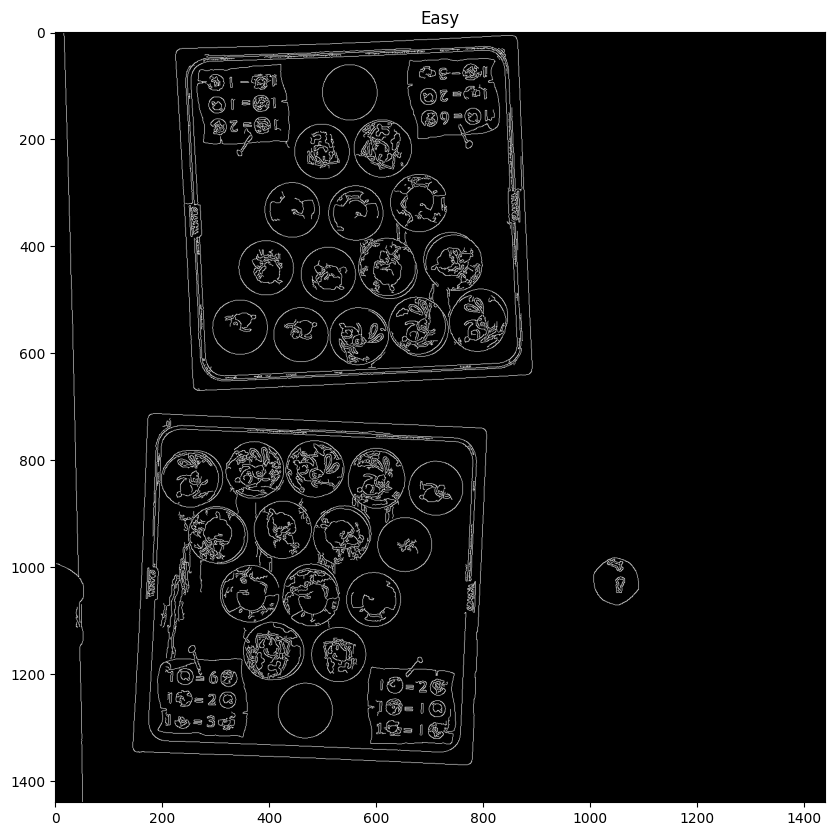

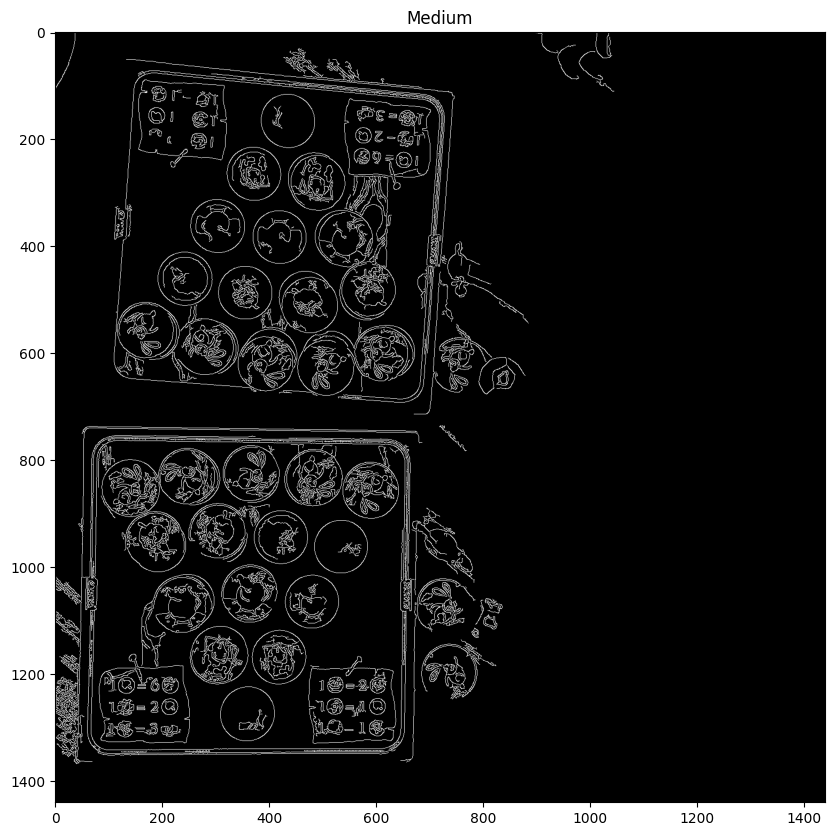

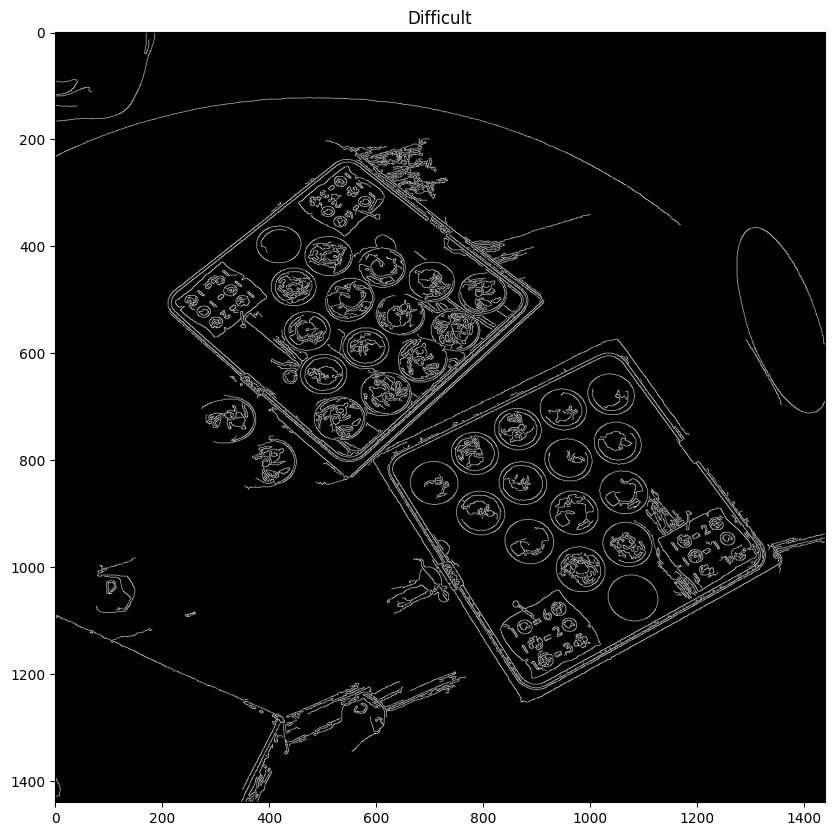

In [30]:
img_easy_gray = cv2.cvtColor(img_easy, cv2.COLOR_BGR2GRAY)
blur_easy = cv2.GaussianBlur(img_easy_gray, (5, 5), 0)
edges_easy = cv2.Canny(blur_easy, 0, 200)

img_medium_gray = cv2.cvtColor(img_medium, cv2.COLOR_BGR2GRAY)
blur_medium = cv2.GaussianBlur(img_medium_gray, (5, 5), 0)
edges_medium = cv2.Canny(blur_medium, 0, 200)

img_difficult_gray = cv2.cvtColor(img_difficult, cv2.COLOR_BGR2GRAY)
blur_difficult = cv2.GaussianBlur(img_difficult_gray, (5, 5), 0)
edges_difficult = cv2.Canny(blur_difficult, 0, 200)

plt.figure(figsize=(10, 10))
plt.imshow(edges_easy, cmap='gray')
plt.title("Easy")
plt.show()

plt.figure(figsize=(10, 10))
plt.imshow(edges_medium, cmap='gray')
plt.title("Medium")
plt.show()

plt.figure(figsize=(10, 10))
plt.imshow(edges_difficult, cmap='gray')
plt.title("Difficult")
plt.show()

# Circles detection

In [34]:
def draw_circles(edges, title:str=""):
    img_circles = edges.copy()
    kernel = np.ones((3, 3), np.uint8)
    img_circles = cv2.dilate(img_circles, kernel, iterations=2)

    circles = cv2.HoughCircles(
        img_circles,
        cv2.HOUGH_GRADIENT,
        dp=1,
        minDist=50,
        param1=100,
        param2=30,
        minRadius=25,
        maxRadius=75
    )

    img_circles = np.stack([img_circles, img_circles, img_circles], axis=2)

    if circles is not None:
        circles = np.uint16(np.around(circles))
        for x, y, r in circles[0]:
            cv2.circle(img_circles, (x, y), r, (255, 255, 0), 2)
            cv2.circle(img_circles, (x, y), 2, (255, 255, 0), 3)

    plt.figure(figsize=(12, 12))
    plt.imshow(img_circles)
    plt.title(title)
    plt.show()

    return circles

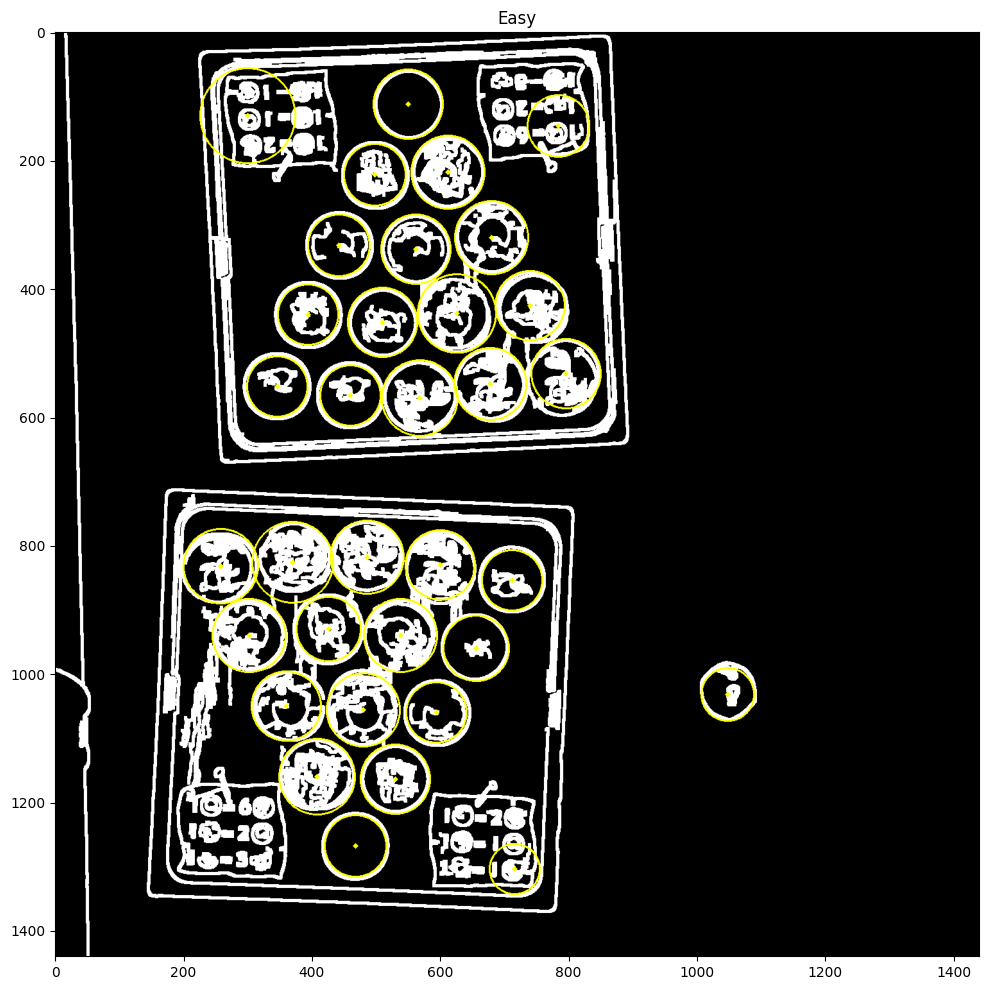

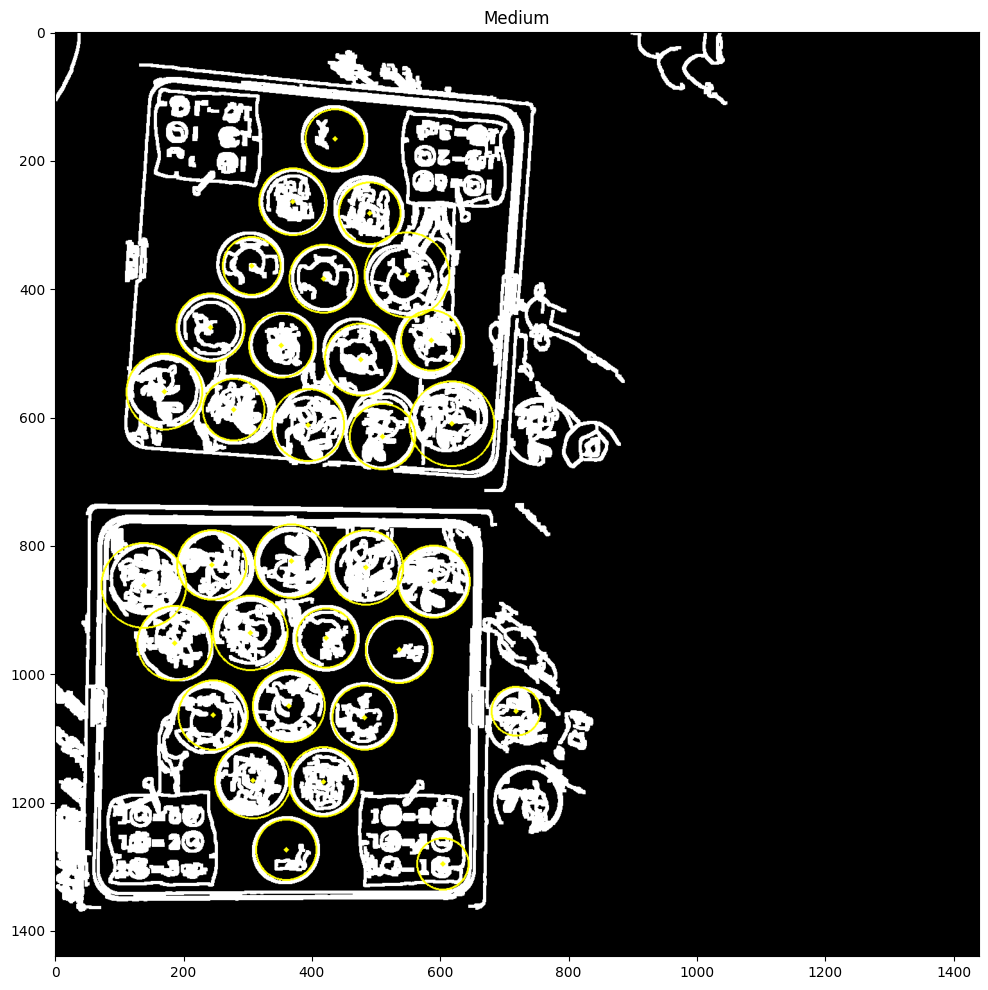

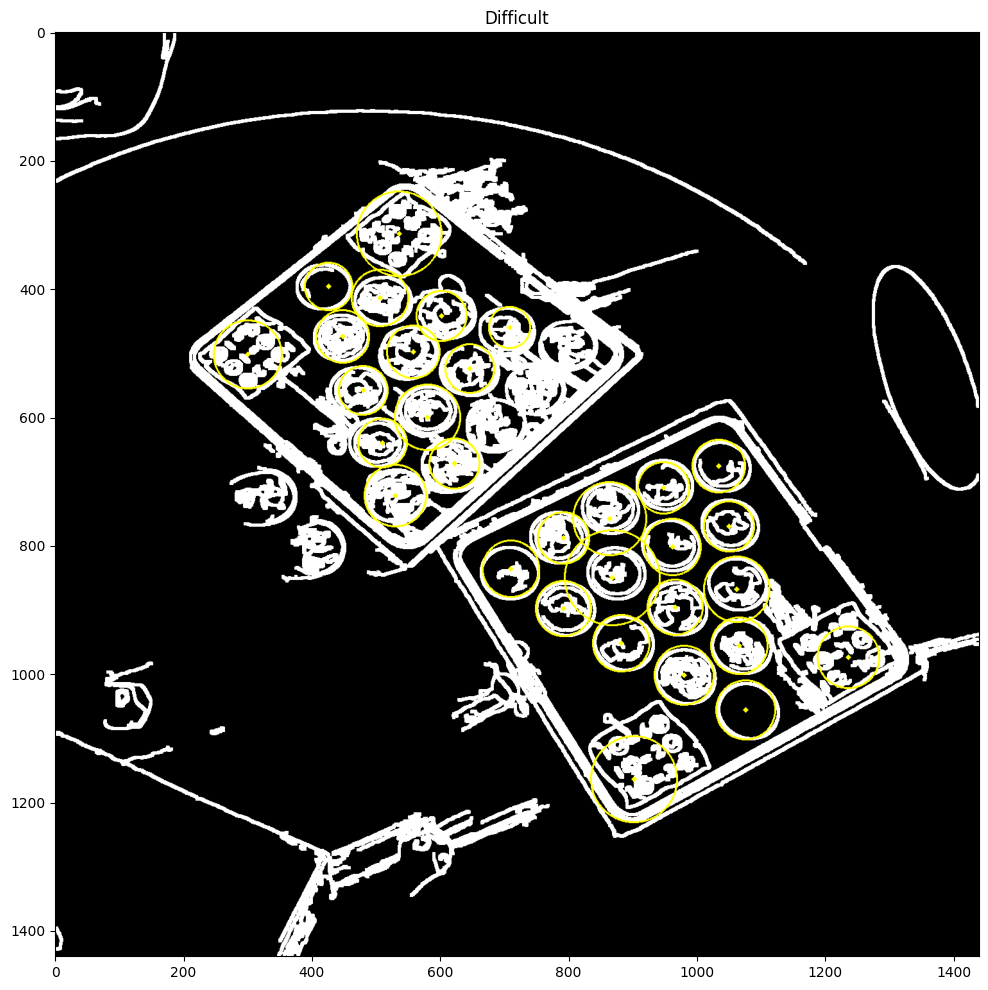

In [35]:
circles_easy = draw_circles(edges_easy, "Easy")
circles_medium = draw_circles(edges_medium, "Medium")
circles_difficult = draw_circles(edges_difficult, "Difficult")

In [37]:
x_easy = [circle[0] for circle in circles_easy[0]]
y_easy = [circle[1] for circle in circles_easy[0]]
r_easy = [circle[2] for circle in circles_easy[0]]
x_medium = [circle[0] for circle in circles_medium[0]]
y_medium = [circle[1] for circle in circles_medium[0]]
r_medium = [circle[2] for circle in circles_medium[0]]
x_difficult = [circle[0] for circle in circles_difficult[0]]
y_difficult = [circle[1] for circle in circles_difficult[0]]
r_difficult = [circle[2] for circle in circles_difficult[0]]

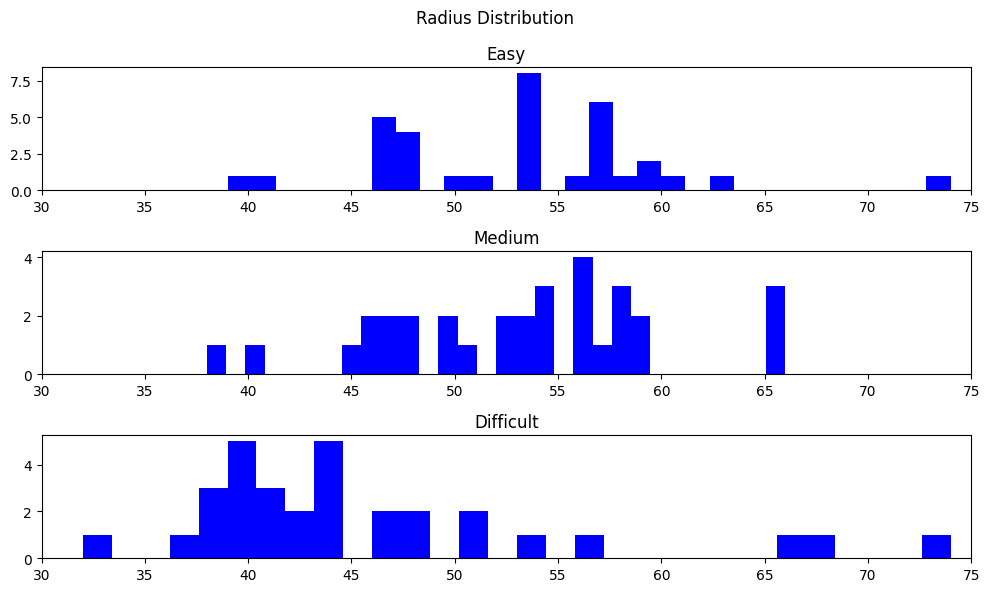

In [47]:
fig, ax = plt.subplots(nrows=3, figsize=(10, 6))
ax[0].hist(r_easy, bins=30, color="blue")
ax[0].set_title("Easy")
ax[0].set_xlim(30, 75)
ax[1].hist(r_medium, bins=30, color="blue")
ax[1].set_title("Medium")
ax[1].set_xlim(30, 75)
ax[2].hist(r_difficult, bins=30, color="blue")
ax[2].set_title("Difficult")
ax[2].set_xlim(30, 75)
plt.suptitle("Radius Distribution")
plt.tight_layout()
plt.show()

# Change color system

In [48]:
img_easy_hsv = cv2.cvtColor(img_easy, cv2.COLOR_RGB2HSV)
img_medium_hsv = cv2.cvtColor(img_medium, cv2.COLOR_RGB2HSV)
img_difficult_hsv = cv2.cvtColor(img_difficult, cv2.COLOR_RGB2HSV)
hue_easy, saturation_easy, value_easy = cv2.split(img_easy_hsv)
hue_medium, saturation_medium, value_medium = cv2.split(img_medium_hsv)
hue_difficult, saturation_difficult, value_difficult = cv2.split(img_difficult_hsv)

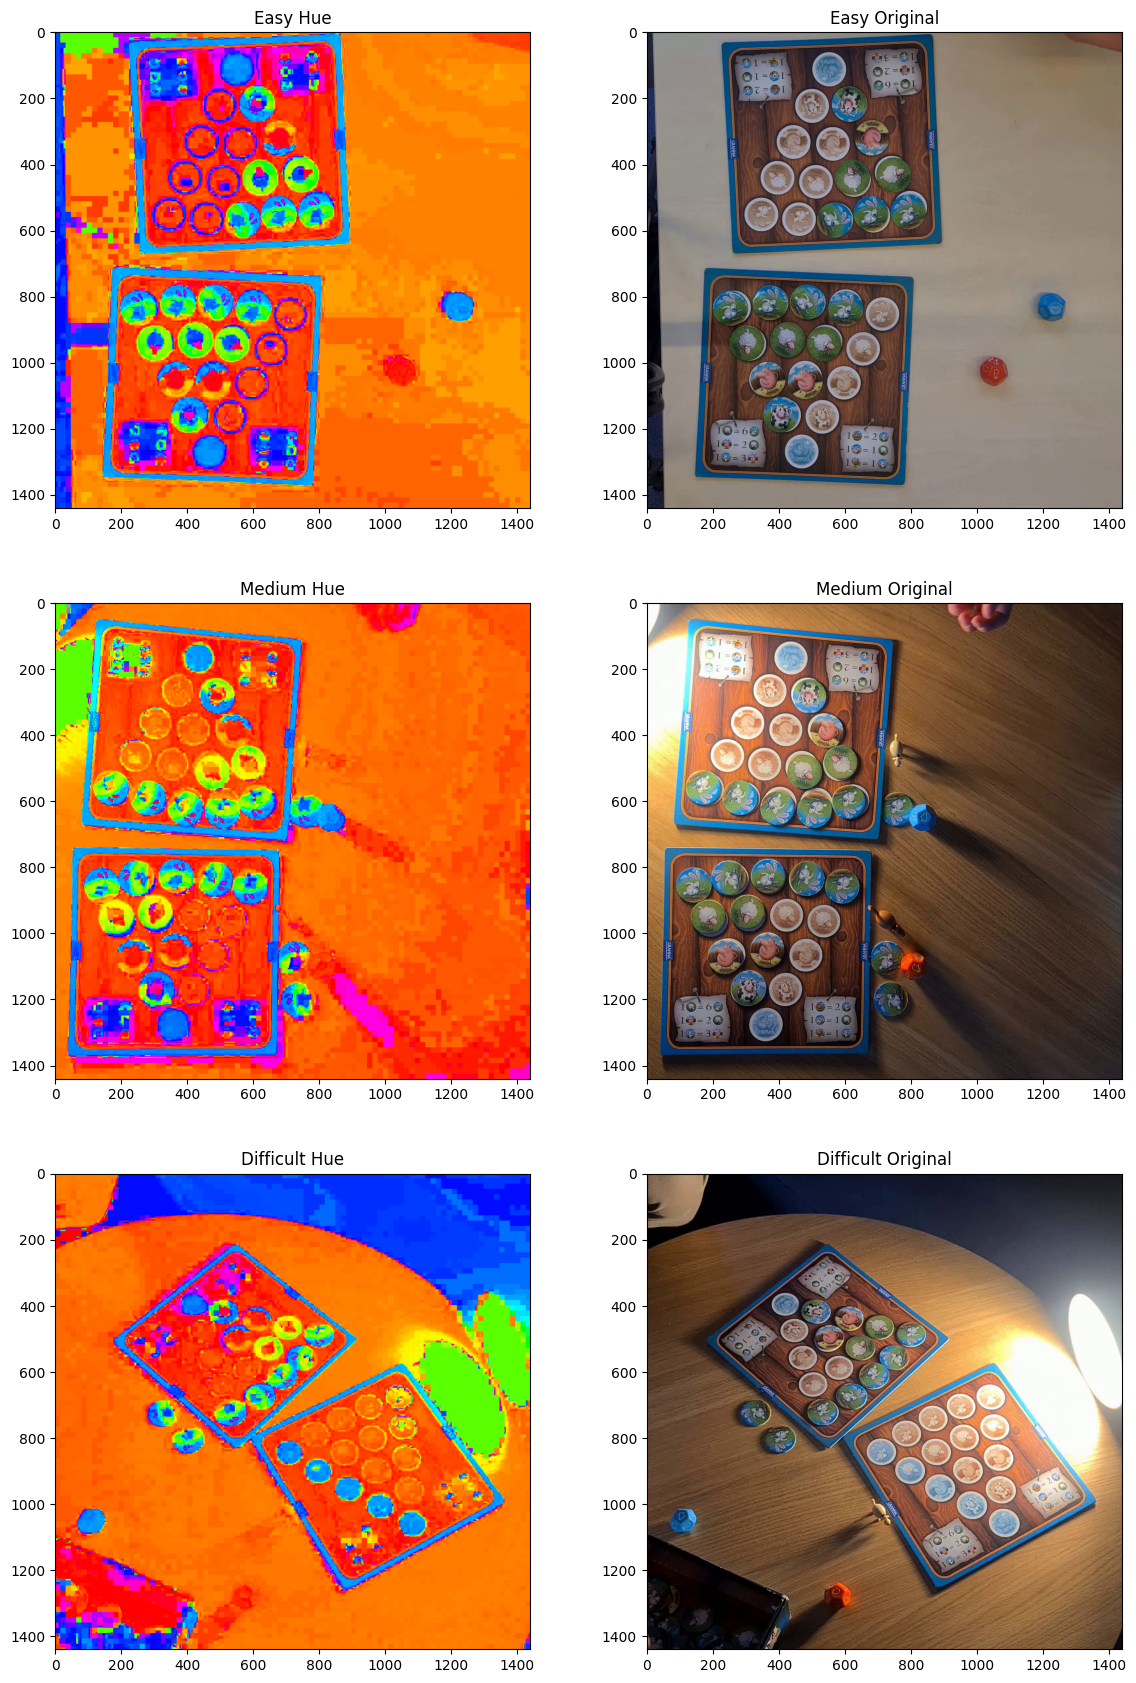

In [50]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(14, 21))
ax[0][0].imshow(hue_easy, cmap="hsv", vmin=0, vmax=179)
ax[0][0].set_title("Easy Hue")
ax[1][0].imshow(hue_medium, cmap="hsv", vmin=0, vmax=179)
ax[1][0].set_title("Medium Hue")
ax[2][0].imshow(hue_difficult, cmap="hsv", vmin=0, vmax=179)
ax[2][0].set_title("Difficult Hue")

ax[0][1].imshow(img_easy)
ax[0][1].set_title("Easy Original")
ax[1][1].imshow(img_medium)
ax[1][1].set_title("Medium Original")
ax[2][1].imshow(img_difficult)
ax[2][1].set_title("Difficult Original")
plt.show()